1. Setup and Dataset Download

In [ ]:
# Install Kaggle API
!pip install kaggle

# Upload the kaggle.json file
from google.colab import files
files.upload()

# Move the kaggle.json file to the correct location
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud

# Extract the dataset
!unzip creditcardfraud.zip


2. Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Load the dataset
df = pd.read_csv('creditcard.csv')

# Display the first few rows
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


3. Data Preprocessing

In [ ]:
# Check for missing values
print(df.isnull().sum())

# Feature Scaling
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original Time and Amount columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Split the data into features and labels
X = df.drop('Class', axis=1)
y = df['Class']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


4. Model Training

In [ ]:
# Train Logistic Regression model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Predict and evaluate
lr_predictions = lr_model.predict(X_test)
print("Logistic Regression Report:")
print(classification_report(y_test, lr_predictions))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.58      0.70        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
rf_predictions = rf_model.predict(X_test)
print("Random Forest Report:")
print(classification_report(y_test, rf_predictions))


Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.80      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.94     56962
weighted avg       1.00      1.00      1.00     56962



6. Visualization and Analysis

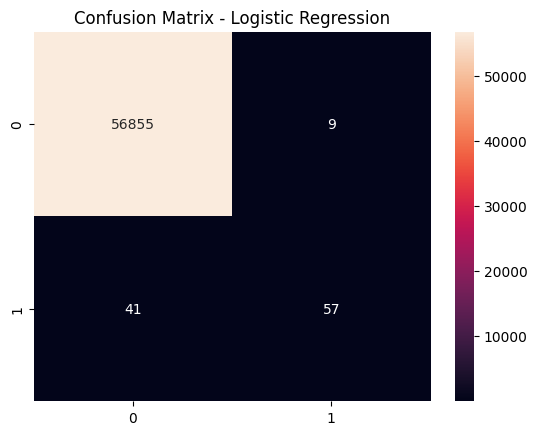

In [ ]:
# Plot confusion matrix for Logistic Regression
conf_matrix_lr = confusion_matrix(y_test, lr_predictions)
sns.heatmap(conf_matrix_lr, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


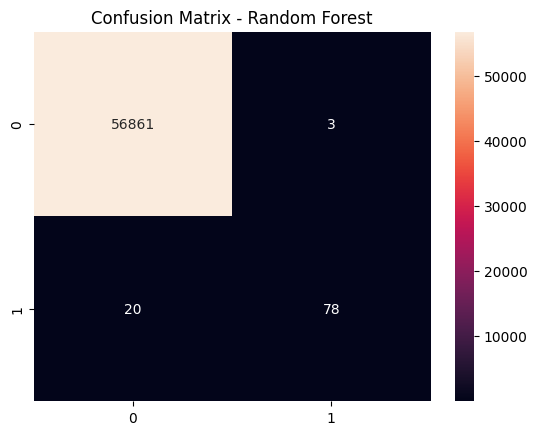

In [ ]:
# Plot confusion matrix for Random Forest
conf_matrix = confusion_matrix(y_test, rf_predictions)
sns.heatmap(conf_matrix, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()


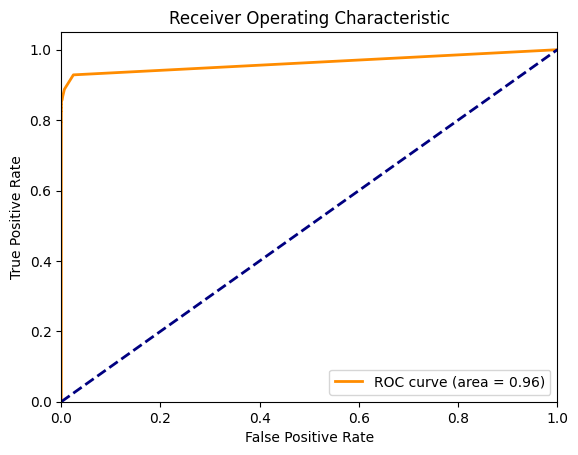

In [ ]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


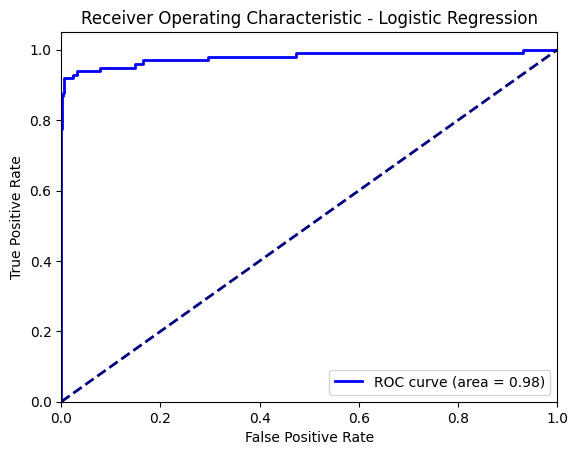

In [ ]:
# Plot ROC Curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:, 1])
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure()
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc_lr:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Logistic Regression')
plt.legend(loc="lower right")
plt.show()


7. Feature Importance

Feature ranking:
1. Feature V17 (0.1766)
2. Feature V12 (0.1240)
3. Feature V14 (0.1164)
4. Feature V11 (0.0853)
5. Feature V10 (0.0846)
6. Feature V16 (0.0454)
7. Feature V18 (0.0359)
8. Feature V9 (0.0281)
9. Feature V4 (0.0261)
10. Feature V7 (0.0247)
11. Feature V26 (0.0184)
12. Feature V3 (0.0182)
13. Feature V2 (0.0154)
14. Feature V6 (0.0151)
15. Feature V1 (0.0150)
16. Feature V20 (0.0138)
17. Feature Recent_Transactions (0.0122)
18. Feature V21 (0.0121)
19. Feature V5 (0.0116)
20. Feature V19 (0.0114)
21. Feature V15 (0.0112)
22. Feature scaled_time (0.0110)
23. Feature V27 (0.0108)
24. Feature V22 (0.0103)
25. Feature scaled_amount (0.0103)
26. Feature V8 (0.0101)
27. Feature V28 (0.0100)
28. Feature V24 (0.0095)
29. Feature V13 (0.0095)
30. Feature V25 (0.0076)
31. Feature V23 (0.0059)
32. Feature Time_Difference (0.0035)


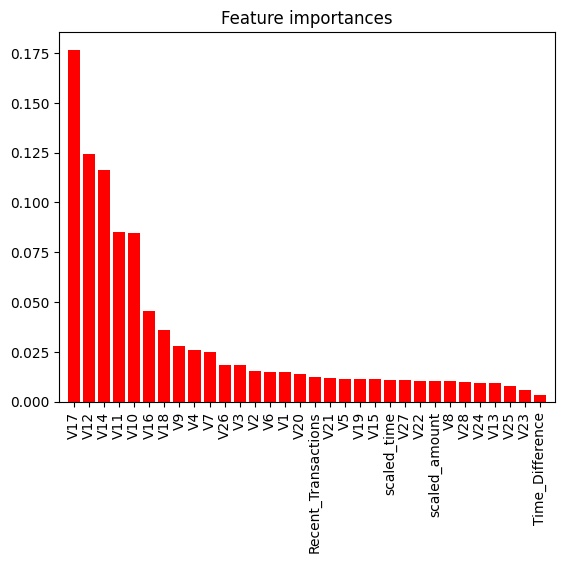

In [ ]:
# Feature importance for Random Forest
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking:")

for f in range(X_train.shape[1]):
    print(f"{f + 1}. Feature {X.columns[indices[f]]} ({importances[indices[f]]:0.4f})")

# Plot the feature importances
plt.figure()
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices], color="r", align="center")
plt.xticks(range(X_train.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


Logistic Regression Coefficients:
                Feature  Coefficient
26                  V27    -0.862202
21                  V22     0.713056
9                   V10    -0.670949
3                    V4     0.661586
13                  V14    -0.621756
30  Recent_Transactions     0.529938
19                  V20    -0.451123
27                  V28    -0.427377
20                  V21     0.391041
29          scaled_time    -0.340295
8                    V9    -0.268367
12                  V13    -0.257021
15                  V16    -0.198120
7                    V8    -0.197183
28        scaled_amount     0.180209
4                    V5     0.132999
0                    V1     0.131532
24                  V25    -0.126108
6                    V7    -0.123864
14                  V15    -0.122666
22                  V23    -0.117787
10                  V11    -0.116822
5                    V6    -0.100245
23                  V24     0.077431
18                  V19     0.066230
2   

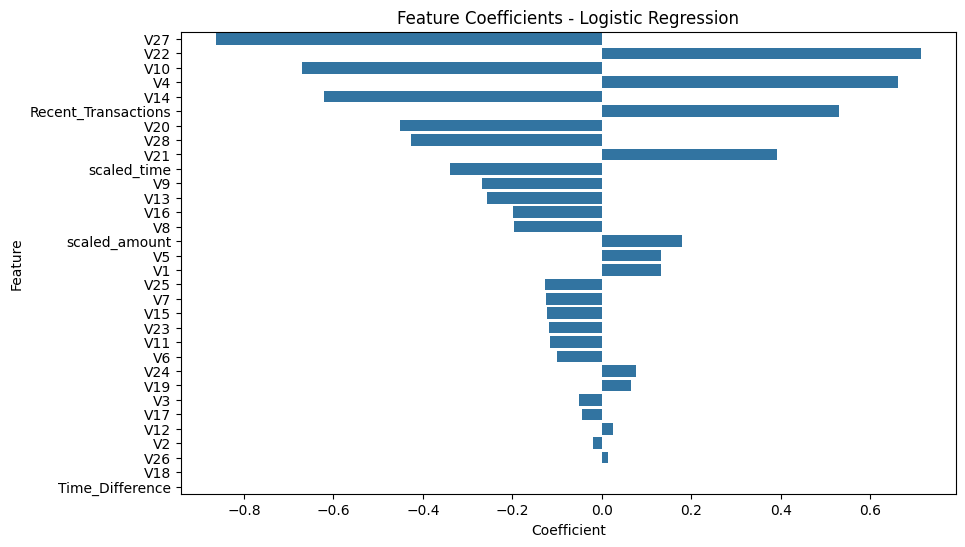

In [ ]:
# Coefficients for Logistic Regression
coefficients = lr_model.coef_[0]
features = X.columns

# Create a DataFrame to display the coefficients
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

# Print the coefficients
print("Logistic Regression Coefficients:")
print(coef_df[['Feature', 'Coefficient']])

# Plot the coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Feature Coefficients - Logistic Regression')
plt.show()
